In [6]:
import sys
import csv
import importlib
from pathlib import Path

import numpy as np

# repo root, found by walking up from wherever this notebook sits
cwd = Path.cwd().resolve()
repo_root = next((c for c in [cwd, *cwd.parents] if (c / "utilities" / "functions.py").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find the repository root containing utilities/functions.py")
sys.path.append(str(repo_root))

import utilities.functions as functions

importlib.reload(functions)

data_root = repo_root / "ms0_5"

IN_all_seq = functions.read_seq(str(data_root / "IN" / "data" / "in.reduce4.seq"))
PR_all_seq = functions.read_seq(str(data_root / "PR" / "data" / "pr.exper.reduce4.seq"))
RT_all_seq = functions.read_seq(str(data_root / "RT" / "data" / "rt.reduce4.seq"))

with open(str(data_root / "IN" / "data" / "in.consensus.reduce4.seq")) as f:
    IN_consensus_seq = f.read().strip()
with open(str(data_root / "PR" / "data" / "pr.consensus.reduce4.seq")) as f:
    PR_consensus_seq = f.read().strip()
with open(str(data_root / "RT" / "data" / "rt.consensus.reduce4.seq")) as f:
    RT_consensus_seq = f.read().strip()

IN_redux = functions.get_redu_dict(str(data_root / "IN" / "data" / "in.reduce4.redux"), 1)
PR_redux = functions.get_redu_dict(str(data_root / "PR" / "data" / "pr.reduce4.redux"), 0)
RT_redux = functions.get_redu_dict(str(data_root / "RT" / "data" / "rt.reduce4.redux"), 0)


def build_J_matrix(j_file, min_position, max_position):
    """Dense coupling tensor, shape (L, L, 4, 5), indexed [p1, p2, aa_at_p1, aa_at_p2]."""
    J = np.load(j_file).astype(np.float32)
    L = max_position - min_position + 1
    Jm = np.zeros((L, L, 4, 5), dtype=np.float32)
    iu0, iu1 = np.triu_indices(L, 1)
    blocks = J.reshape(-1, 4, 4)
    assert blocks.shape[0] == iu0.size, "J.npy row count does not match the position range"
    Jm[iu0, iu1, :, :4] = blocks
    Jm[iu1, iu0, :, :4] = blocks.transpose(0, 2, 1)
    return Jm


IN_J = build_J_matrix(str(data_root / "IN" / "data" / "J.npy"), 1, 263)
PR_J = build_J_matrix(str(data_root / "PR" / "data" / "J_PR.npy"), 1, 99)
RT_J = build_J_matrix(str(data_root / "RT" / "data" / "J_RT.npy"), 39, 226)

print("alignments:", len(IN_all_seq), "IN /", len(PR_all_seq), "PR /", len(RT_all_seq), "RT")

alignments: 1220 IN / 5710 PR / 19194 RT


In [7]:
# =============================================================================
# Which run these figures describe.
#
# The thresholds and switches below only pick the input: the pair list for the left figure
# and the probability CSVs for the right one. They must match the run of
# DMC_sebset_freq2.7.1_c_overlap_flag.ipynb that produced those CSVs, which is why the
# naming rule is repeated here rather than guessed.
# =============================================================================
PROTEIN_A = 'RT'                                       # protein drawn in the left figure
DMC_MIN_PERCENT = {'IN': 1.0, 'PR': 5.0, 'RT': 5.0}    # carrier cut, per protein
TOP_N_PAIRS = 20
CSV_VERSION = 'v17'
USE_TOP_DDE_PAIRS = True
NON_OVERLAPPING = False        # False -> the "_with_overlap" CSVs
RT_COMBINED = True             # RT as a whole, not split into NRTI / NNRTI

CFG = {
    'IN': (IN_all_seq, IN_consensus_seq, IN_redux, IN_J, 1, 263,
           'IN_top_1000_dde_summary.csv', 'INSTI'),
    'PR': (PR_all_seq, PR_consensus_seq, PR_redux, PR_J, 1, 99,
           'PR_top_1000_dde_summary.csv', 'PI'),
    'RT': (RT_all_seq, RT_consensus_seq, RT_redux, RT_J, 39, 226,
           'RT_NRTI_top_1000_dde_summary.csv', 'NRTI/NNRTI'),
}


def top_dde_pairs(protein):
    """The ms0_5 top-ddE pairs that clear this protein's carrier threshold."""
    seqs, _, _, _, _, _, dde_file, _ = CFG[protein]
    with open(data_root / dde_file, newline='') as f:
        rows = list(csv.DictReader(f))
    cut = len(seqs) * DMC_MIN_PERCENT[protein] / 100.0
    kept = [r['double_mutation_pair'] for r in rows if float(r['both_count']) > cut]
    return kept[:TOP_N_PAIRS] if TOP_N_PAIRS is not None else kept


def csv_name(stem, protein):
    """Probability-CSV name, following DMC_sebset_freq2.7.1's out_name()."""
    tags = [f"{stem}_{CSV_VERSION}"]
    if USE_TOP_DDE_PAIRS:
        tags.append(f"topdde_{DMC_MIN_PERCENT[protein]:g}pct")
        if TOP_N_PAIRS is not None:
            tags.append(f"top{TOP_N_PAIRS}")
    if not NON_OVERLAPPING:
        tags.append("with_overlap")
    return "_".join(tags) + ".csv"


# ---------------------------------------------------------------------------
# energies -- only what the left figure needs (no contender scan, so this stays fast)
# ---------------------------------------------------------------------------
_AA_CODE = np.full(256, 4, dtype=np.uint8)
for _i, _c in enumerate("ABCD"):
    _AA_CODE[ord(_c)] = _i


def encode_seqs(seq_list, min_pos, max_pos):
    L = max_pos - min_pos + 1
    N = len(seq_list)
    raw = np.frombuffer("".join(seq_list).encode(), dtype=np.uint8)
    assert raw.size == N * L, "all sequences must span exactly min_pos..max_pos"
    codes = _AA_CODE[raw.reshape(N, L)]
    onehot = np.zeros((N * L, 5), dtype=np.float32)
    onehot[np.arange(N * L), codes.ravel()] = 1.0
    return codes, onehot.reshape(N, L * 5)


def _site_energies(onehot, Jm, p, excluded):
    A = Jm[p].copy()
    A[list(excluded)] = 0.0
    return np.asarray(onehot @ A.transpose(0, 2, 1).reshape(-1, 4), dtype=np.float64)


def de_double(onehot, Jm, p1i, p2i, wt1, mt1, wt2, mt2):
    """dE double = E(wild type at both positions) - E(double mutant), per sequence."""
    S1 = _site_energies(onehot, Jm, p1i, (p1i, p2i))
    S2 = _site_energies(onehot, Jm, p2i, (p1i, p2i))
    J12 = Jm[p1i, p2i, :, :4].astype(np.float64)
    M = S1[:, :, None] + S2[:, None, :] + J12[None, :, :]
    return M[:, wt1, wt2] - M[:, mt1, mt2]


print(f"left figure: {PROTEIN_A}, {len(top_dde_pairs(PROTEIN_A))} pairs at "
      f"{DMC_MIN_PERCENT[PROTEIN_A]}%")
print("right figure reads:")
for _p, _stem in (('IN', 'integrase_all_probabilities'), ('PR', 'protease_all_probabilities'),
                  ('RT', 'reverseTranscriptase_both_probabilities')):
    print("  ", csv_name(_stem, _p))

left figure: RT, 20 pairs at 5.0%
right figure reads:
   integrase_all_probabilities_v17_topdde_1pct_top20_with_overlap.csv
   protease_all_probabilities_v17_topdde_5pct_top20_with_overlap.csv
   reverseTranscriptase_both_probabilities_v17_topdde_5pct_top20_with_overlap.csv


In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# =============================================================================
# One typography and colour scheme for both figures, so they sit side by side on a page.
#
# Minimal chrome throughout: no frames on legends, no top/right spines, hairline grid, ink
# text rather than coloured text, and every legend reduced to a single line of small marks.
# Sizes are set for a figure that will be printed at roughly the width it is drawn.
# =============================================================================
SURFACE, INK, INK2, MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#898781'
GRID, BASE, CONTEXT = '#e6e5df', '#c3c2b7', '#d3d2cc'

# the colours the original observed-vs-expected notebooks used, kept so these figures sit
# beside the earlier versions without the series changing hue
S1, S2, S3 = '#1f77b4', '#ff7f0e', '#2ca02c'      # INSTI / PI / NRTI-NNRTI
CARRIER, NON_CARRIER = S1, S2                     # left figure: carriers / non-carriers
DRUG_COLOR = {'INSTI': S1, 'PI': S2, 'NRTI/NNRTI': S3}

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'font.size': 9, 'axes.titlesize': 9.5, 'axes.labelsize': 9,
    'axes.edgecolor': BASE, 'axes.labelcolor': INK2, 'axes.linewidth': 0.7,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'xtick.labelsize': 8,
    'ytick.labelsize': 8, 'text.color': INK,
    'grid.color': GRID, 'grid.linewidth': 0.6, 'legend.frameon': False,
    'lines.solid_capstyle': 'round',
})


def bare(ax, grid=None):
    """Strip an axis down to a baseline and, optionally, one direction of hairline grid."""
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(BASE)
    ax.tick_params(length=0, pad=2)
    if grid:
        ax.grid(axis=grid, color=GRID, linewidth=0.6)
        ax.set_axisbelow(True)
    return ax


def strip_legend(ax, handles, y=1.005, ncol=4):
    """A legend that is one line of marks above the axes -- no frame, no box, no title."""
    return ax.legend(handles=handles, loc='lower left', bbox_to_anchor=(0, y), ncol=ncol,
                     fontsize=8, labelcolor=INK2, handletextpad=0.35, columnspacing=1.1,
                     borderaxespad=0, handlelength=1.4)


def save(fig, name):
    fig.savefig(f"{name}.png", dpi=1000, bbox_inches='tight', pad_inches=0.02,
                facecolor=SURFACE)
    fig.savefig(f"{name}.pdf", bbox_inches='tight', pad_inches=0.02, facecolor=SURFACE)
    print("saved", name + ".png / .pdf")


print("style ready")

style ready


saved fig_consensus_vs_realized_RT.png / .pdf


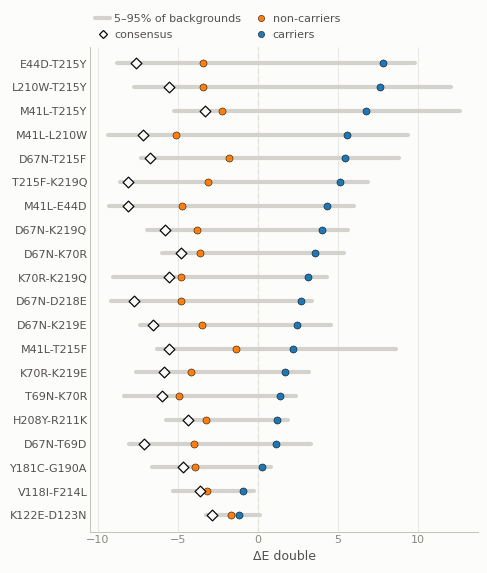

In [9]:
# =============================================================================
# LEFT FIGURE -- dE double on the consensus background against dE double where the pair is
# actually found. One row per pair:
#
#     grey bar      5th-95th percentile of dE double over every background in the alignment
#     open diamond  the consensus background: the single number one would normally report
#     orange dot    mean over sequences that do not carry the pair
#     blue dot      mean over sequences that do
#
# Minimal version of the archived figure A: the four-entry boxed legend becomes one line of
# marks above the plot, rows are tighter, marks are smaller, and the summary sentence is left
# to the caption instead of sitting on the figure.
# =============================================================================
seqs, cons, redux, J, MIN_POS, MAX_POS, _, DRUG = CFG[PROTEIN_A]
pairs = top_dde_pairs(PROTEIN_A)

codes, onehot = encode_seqs(seqs, MIN_POS, MAX_POS)
_, cons_onehot = encode_seqs([cons], MIN_POS, MAX_POS)

rows = []
for name in pairs:
    a, b = functions.split_pairs(name)
    wt1, pos1, mt1 = functions.split_pair(functions.unreduced_to_reduced(redux, a))
    wt2, pos2, mt2 = functions.split_pair(functions.unreduced_to_reduced(redux, b))
    idx = (pos1 - MIN_POS, pos2 - MIN_POS, "ABCD".index(wt1), "ABCD".index(mt1),
           "ABCD".index(wt2), "ABCD".index(mt2))
    de = de_double(onehot, J, *idx)
    dmc = (codes[:, idx[0]] == idx[3]) & (codes[:, idx[1]] == idx[5])
    lo, hi = np.percentile(de, [5, 95])
    rows.append(dict(name=name, lo=lo, hi=hi, cons=float(de_double(cons_onehot, J, *idx)[0]),
                     carrier=de[dmc].mean() if dmc.any() else np.nan,
                     other=de[~dmc].mean()))

rows.sort(key=lambda r: r['carrier'])
y = np.arange(len(rows))

fig, ax = plt.subplots(figsize=(5.0, 0.26 * len(rows) + 1.1))
for i, r in enumerate(rows):
    ax.plot([r['lo'], r['hi']], [i, i], color=CONTEXT, lw=3.0, zorder=1)
ax.axvline(0, color=BASE, ls=(0, (4, 3)), lw=0.8, zorder=0)
ax.scatter([r['other'] for r in rows], y, s=26, color=NON_CARRIER, edgecolors='black',
           linewidth=0.35, zorder=3)
ax.scatter([r['carrier'] for r in rows], y, s=26, color=CARRIER, edgecolors='black',
           linewidth=0.35, zorder=3)
ax.scatter([r['cons'] for r in rows], y, s=30, marker='D', facecolor=SURFACE,
           edgecolor=INK, lw=0.9, zorder=4)

ax.set_yticks(y, [r['name'] for r in rows], fontsize=8, color=INK2)
ax.set_ylim(-0.7, len(rows) - 0.3)
ax.set_xlabel('ΔE double')
bare(ax, grid='x')
strip_legend(ax, [
    Line2D([], [], color=CONTEXT, lw=3.0, label='5–95% of backgrounds'),
    Line2D([], [], marker='D', color=INK, markerfacecolor=SURFACE, markersize=4.5, lw=0,
           markeredgewidth=0.9, label='consensus'),
    Line2D([], [], marker='o', color=NON_CARRIER, lw=0, markersize=4.5,
           markeredgecolor='black', markeredgewidth=0.35, label='non-carriers'),
    Line2D([], [], marker='o', color=CARRIER, lw=0, markersize=4.5,
           markeredgecolor='black', markeredgewidth=0.35, label='carriers'),
], ncol=2)

save(fig, f'fig_consensus_vs_realized_{PROTEIN_A}')
plt.show()

saved fig_observed_vs_expected_with_overlap.png / .pdf


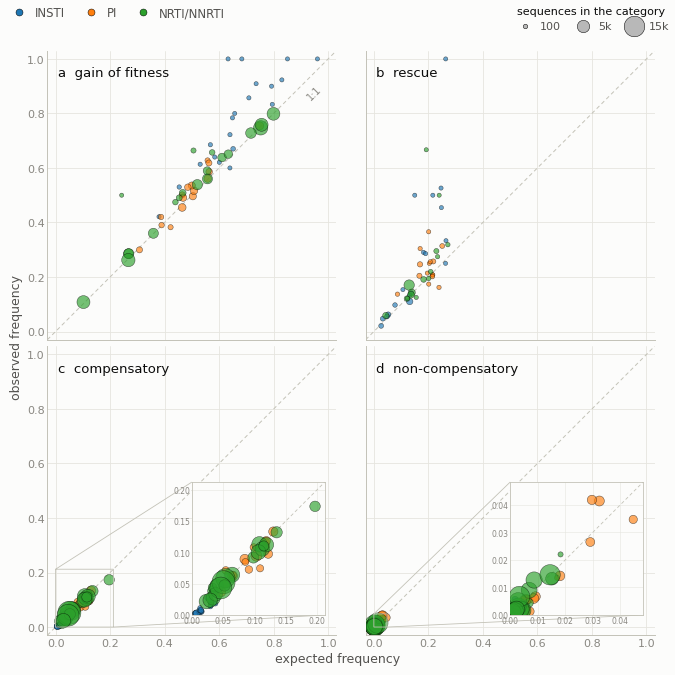

In [10]:
import pandas as pd

# =============================================================================
# RIGHT FIGURE -- observed against expected frequency, one panel per epistasis category.
#
# Same content as plot_obs_vs_exp_v2.3, drawn tighter:
#   * the four panels share one pair of axes, so the axis labels appear once on the figure
#     rather than eight times, and the panels can sit flush against each other
#   * one legend, in the first panel only, as three marks with no frame; the 1:1 line is
#     labelled inline instead of taking a legend row
#   * both keys sit above the panels on one line -- the three drug colours on the left, the
#     marker-size key on the right -- instead of a legend per panel and a full-width size
#     strip under the figure
#   * the zoom insets stay -- the two low-frequency categories are unreadable on the shared
#     scale without them -- but lose their titles and heavy frames
# =============================================================================
STEMS = {'INSTI': ('integrase_all_probabilities', 'IN'),
         'PI': ('protease_all_probabilities', 'PR'),
         'NRTI/NNRTI': ('reverseTranscriptase_both_probabilities', 'RT')}
DFS = {drug: pd.read_csv(csv_name(stem, prot)) for drug, (stem, prot) in STEMS.items()}

CATEGORIES = [('Gain_of_function', 'gain of fitness'), ('rescue', 'rescue'),
              ('compensatory', 'compensatory'), ('non_compensatory', 'non-compensatory')]
INSET_ON = {'compensatory', 'non_compensatory'}


def cat_data(df, category):
    d = df[df['epistasis_subset'] == category].dropna(
        subset=['average_p_subcategory', 'observed_f_subcategory'])
    return d[(d['average_p_subcategory'] != 0) & (d['observed_f_subcategory'] != 0)]


def msize(num_seqs):
    """Marker area, linear in the number of sequences carrying the pair."""
    return np.asarray(num_seqs, dtype=float) / 10000 * 140 + 9


def draw(ax, key, alpha=0.65):
    for drug, df in DFS.items():
        d = cat_data(df, key)
        if len(d):
            ax.scatter(d['average_p_subcategory'], d['observed_f_subcategory'],
                       s=msize(d['num_seqs']), color=DRUG_COLOR[drug], alpha=alpha,
                       edgecolors='black', linewidth=0.35, zorder=3)


all_vals = np.concatenate([np.r_[cat_data(df, k)['average_p_subcategory'].values,
                                 cat_data(df, k)['observed_f_subcategory'].values]
                           for k, _ in CATEGORIES for df in DFS.values()])
lim = [-0.03, all_vals.max() + 0.03]

fig, axes = plt.subplots(2, 2, figsize=(6.6, 6.6), sharex=True, sharey=True,
                         layout='constrained')
fig.get_layout_engine().set(w_pad=0.02, h_pad=0.02, wspace=0.02, hspace=0.02)

for n, ((key, label), ax) in enumerate(zip(CATEGORIES, axes.ravel())):
    draw(ax, key)
    ax.plot(lim, lim, color=BASE, ls=(0, (4, 3)), lw=0.7, zorder=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal')
    bare(ax, grid='both')
    ax.text(0.035, 0.945, f'{"abcd"[n]}  {label}', transform=ax.transAxes, fontsize=9.5,
            color=INK, va='top')

    if n == 0:      # the 1:1 line is labelled once, inline, instead of taking a legend row
        ax.text(0.925, 0.855, '1:1', transform=ax.transAxes, fontsize=7, color=MUTED,
                rotation=45, ha='center', va='center')

    if key in INSET_ON:
        vals = np.concatenate([np.r_[cat_data(df, key)['average_p_subcategory'].values,
                                     cat_data(df, key)['observed_f_subcategory'].values]
                               for df in DFS.values()])
        pad = 0.08 * (vals.max() - vals.min())
        zoom = [max(0.0, vals.min() - pad), vals.max() + pad]
        axins = ax.inset_axes([0.50, 0.07, 0.46, 0.46])
        draw(axins, key)
        axins.plot(zoom, zoom, color=BASE, ls=(0, (4, 3)), lw=0.6, zorder=1)
        axins.set_xlim(zoom)
        axins.set_ylim(zoom)
        axins.set_aspect('equal')
        axins.tick_params(labelsize=5.5, length=0, pad=1)
        axins.grid(color=GRID, linewidth=0.4)
        axins.set_axisbelow(True)
        for s in axins.spines.values():
            s.set_color(BASE)
            s.set_linewidth(0.6)
        ax.indicate_inset_zoom(axins, edgecolor=BASE, alpha=1, linewidth=0.6)


# both keys on one line above the panels: drugs left, marker size right
fig.legend(handles=[Line2D([], [], marker='o', color=c, lw=0, markersize=5,
                           markeredgecolor='black', markeredgewidth=0.35, label=d)
                    for d, c in DRUG_COLOR.items()],
           loc='outside upper left', ncol=3, fontsize=8.5, labelcolor=INK2,
           handletextpad=0.35, columnspacing=1.2, borderaxespad=0.2)
fig.legend(handles=[Line2D([], [], marker='o', color='0.72', lw=0,
                           markersize=np.sqrt(msize(v)), markeredgecolor='black',
                           markeredgewidth=0.35,
                           label=f'{v // 1000}k' if v >= 1000 else f'{v}')
                    for v in (100, 5000, 15000)],
           loc='outside upper right', ncol=3, fontsize=8, labelcolor=INK2,
           title='sequences in the category', title_fontsize=8,
           handletextpad=0.35, columnspacing=1.0, borderaxespad=0.2)
fig.get_layout_engine().set(rect=(0, 0, 1, 0.995))

fig.supxlabel('expected frequency', fontsize=9, color=INK2)
fig.supylabel('observed frequency', fontsize=9, color=INK2)

save(fig, 'fig_observed_vs_expected' + ('' if NON_OVERLAPPING else '_with_overlap'))
plt.show()